In [3]:
import numpy as np
import pandas as pd
import plotly.express as px


In [4]:
calls=pd.read_csv("911.csv")

In [36]:
calls.head(20)

,lat,lng,desc,zip,title,timeStamp,twp,addr,day,month,hour,Type of Emergency
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,Thursday,12,17,EMS
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,Thursday,12,17,EMS
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,Thursday,12,17,Fire
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,Thursday,12,17,EMS
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,Thursday,12,17,EMS
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 17:40:01,LANSDALE,CANNON AVE & W 9TH ST,Thursday,12,17,EMS
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,2015-12-10 17:40:01,HORSHAM,LAUREL AVE & OAKDALE AVE,Thursday,12,17,EMS
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,2015-12-10 17:40:01,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,Thursday,12,17,EMS
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,2015-12-10 17:40:01,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,Thursday,12,17,EMS
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 17:40:01,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,Thursday,12,17,Traffic


In [5]:
#cleaning the duplicates and the unnecessary column "e"
calls.drop_duplicates(keep="first",inplace=True)
calls.drop(labels="e",axis=1,inplace=True)

#making sure that the column "timeStamp" is in a "ns" form and creating 3 other columns based on the time stamps.
calls["timeStamp"]=pd.to_datetime(calls["timeStamp"])
calls["day"]=calls["timeStamp"].dt.day_name()
calls["month"]=calls["timeStamp"].dt.month
calls["hour"]=calls["timeStamp"].dt.hour

In [21]:
#after the adjustments above.
calls.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,day,month,hour
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,Thursday,12,17
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,Thursday,12,17
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,Thursday,12,17
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,Thursday,12,17
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,Thursday,12,17


In [6]:
#now, we will extract the code of the emergencies(EMS,Fire for instance...)
calls["Type of Emergency"]=calls["title"].str.split(":").str[0]

In [7]:
# let us examine the status of NaN's
calls.isna().sum()

lat                      0
lng                      0
desc                     0
zip                  12855
title                    0
timeStamp                0
twp                     43
addr                   519
day                      0
month                    0
hour                     0
Type of Emergency        0
dtype: int64

In [8]:
#the number of NaN's in "zip" column is super high. There is no need to drop the NaN's since that would underestimate the total call
#load of a region. We know the coordinates (lat,lng) of every call 911 received. So we won't drop any NaN's. We will fill them instead.
calls.fillna({"zip":0,"twp":"Unknown","addr":"Unknown"},inplace=True) #twp stands for the towns and addr stands for the adresses.

In [47]:
#the status of the data frame after the necessary adjustments.
calls.head(5)

,lat,lng,desc,zip,title,timeStamp,twp,addr,day,month,hour,Type of Emergency
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,Thursday,12,17,EMS
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,Thursday,12,17,EMS
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,Thursday,12,17,Fire
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,Thursday,12,17,EMS
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,0.0,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,Thursday,12,17,EMS


In [9]:
#the top five towns which had the most number of calls.
callsbytown=calls.groupby("twp")["lat"].count().reset_index()
callsbytown.columns=["Town","Number of Calls"]
callsbytown.sort_values(by="Number of Calls",ascending=False,inplace=True)
top5=callsbytown.head(5)
top5
#there is something wrong with "Lower Merion" !!!

,Town,Number of Calls
26,LOWER MERION,8443
0,ABINGTON,5977
35,NORRISTOWN,5890
57,UPPER MERION,5227
6,CHELTENHAM,4575


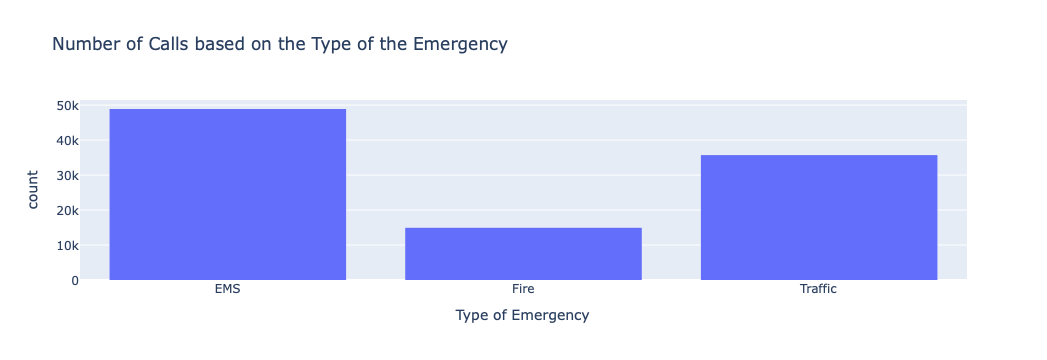

In [10]:
#let us visualize what the data tells us!
hist=px.histogram(data_frame=calls,x="Type of Emergency",title="Number of Calls based on the Type of the Emergency")
hist.show()


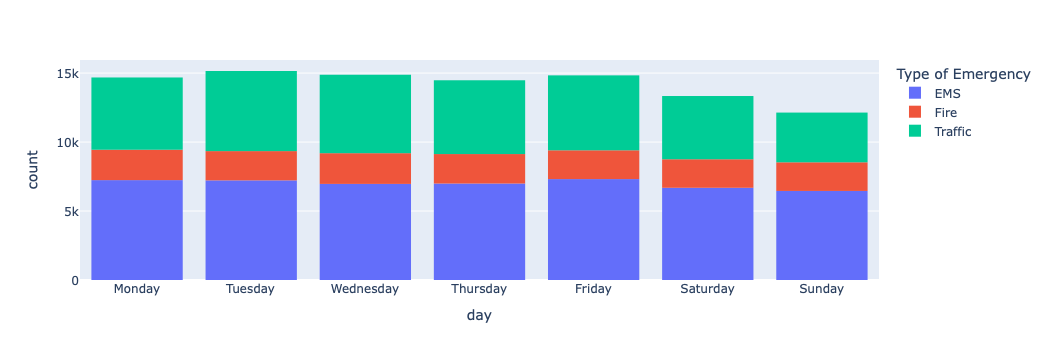

In [11]:
orderofdays=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hist2=px.histogram(data_frame=calls,x="day",color="Type of Emergency",category_orders={"day":orderofdays})
hist2.show()

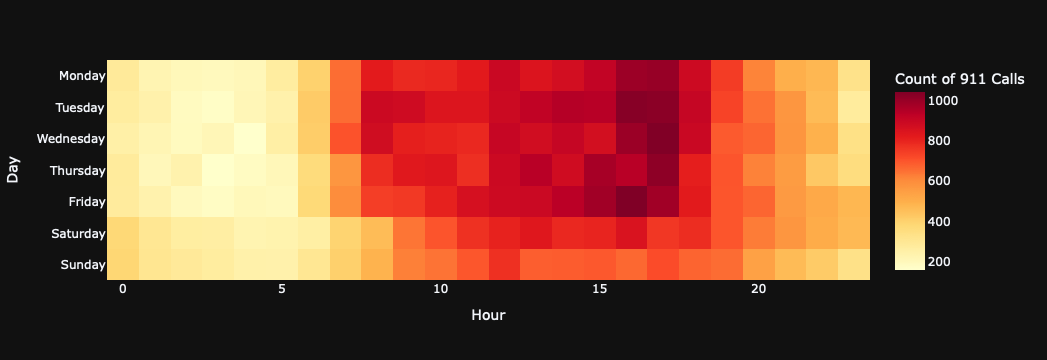

In [24]:
matrix=pd.crosstab(calls["day"],calls["hour"])
matrix=matrix.reindex(orderofdays)
px.imshow(matrix,labels=dict(x="Hour",y="Day",color="Count of 911 Calls"),color_continuous_scale="YlOrRd", template="plotly_dark",aspect="ratio")

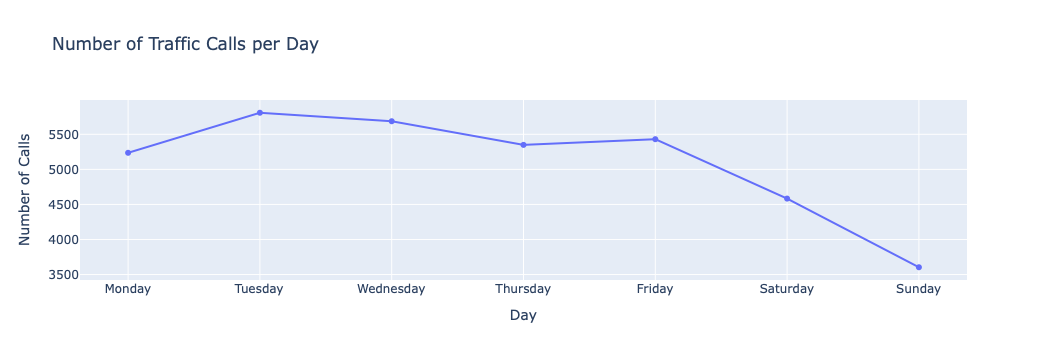

In [23]:
traffic_counts=calls[calls["Type of Emergency"]=="Traffic"]["day"].value_counts().reindex(orderofdays).reset_index()
traffic_counts.columns=["Day","Number of Calls"]
tf=px.line(data_frame=traffic_counts,x="Day",y="Number of Calls",markers=True,title="Number of Traffic Calls per Day")
tf.show()